#**Potato Leaf Disease Detection using Image Classification**

**Project Description**

This project focuses on building an image classification model to detect and classify potato plant
diseases. The dataset consists of high-resolution images of potato leaves categorized into three
classes: Early Blight, Late Blight, and Healthy leaves. The goal is to develop a robust deep
learning model that can accurately identify plant diseases and support agricultural diagnostics.


**Objectives**

● Understand image classification using deep learning

● Perform data preprocessing and augmentation

● Train and evaluate a CNN-based model

#**1. Data Understanding**

**Load data from zip file**

In [ ]:
import zipfile
import os

zip_path = "PotatoPlants1.zip"   # your uploaded file
extracted_path = "/content/dataset"          # where to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_path)

print("Extracted to:", extracted_path)
path = "/content/dataset/PotatoPlants"

Extracted to: /content/dataset


**List all sub directories**

In [ ]:
import os
print(os.listdir(path))

['Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight']


**Display 5 images in each folder**

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 12))
i = 1

for main_folder in os.listdir(path):
    main_path = os.path.join(path, main_folder)

    if os.path.isdir(main_path):
        for sub_folder in os.listdir(main_path):
            sub_path = os.path.join(main_path, sub_folder)

            if os.path.isdir(sub_path):
                images = os.listdir(sub_path)[:5]  # take 5 images

                for img_name in images:
                    img_path = os.path.join(sub_path, img_name)

                    # Skip if it's not a file
                    if not os.path.isfile(img_path):
                        continue

                    try:
                        img = Image.open(img_path)

                        plt.subplot(10, 5, i)
                        plt.imshow(img)
                        plt.title(sub_folder)
                        plt.axis('off')

                        i += 1
                    except:
                        continue  # skip corrupted files

plt.tight_layout()
plt.show()

<Figure size 1500x1200 with 0 Axes>

**count the number of images in each folder**

In [ ]:
for x in os.listdir(path):
  class_path = os.path.join(path,x)
  count = len(os.listdir(class_path))
  print(x ,'-->',count)

Potato___Early_blight --> 1000
Potato___healthy --> 152
Potato___Late_blight --> 1000


**Create dataframe with image path and labels**

In [ ]:
import pandas as pd
df =[]
for label in os.listdir(path):
  class_path = os.path.join(path,label)
  if os.path.isdir(class_path):
    for img in os.listdir(class_path):
      img_path = os.path.join(class_path,img)
      df.append([img_path,label])
data = pd.DataFrame(df,columns=['img_path','label'])


In [ ]:
data

,img_path,label
0,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
1,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
2,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
3,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
4,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
...,...,...
2147,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
2148,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
2149,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
2150,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight


In [ ]:
data = data.sample(frac=1,random_state=42).reset_index()
data

,index,img_path,label
0,1505,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
1,1660,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
2,889,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
3,306,/content/dataset/PotatoPlants/Potato___Early_b...,Potato___Early_blight
4,1771,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
...,...,...,...
2147,1638,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight
2148,1095,/content/dataset/PotatoPlants/Potato___healthy...,Potato___healthy
2149,1130,/content/dataset/PotatoPlants/Potato___healthy...,Potato___healthy
2150,1294,/content/dataset/PotatoPlants/Potato___Late_bl...,Potato___Late_blight


**find height and width of an image**

In [ ]:
from PIL import Image
import os

# Get the full path to an image from the DataFrame
img_path_to_open = data['img_path'][0]

# Open the image directly using its path
img = Image.open(img_path_to_open)

# Correct order: width, height
width, height = img.size

print('Width:', width, 'Height:', height)


Width: 256 Height: 256


**Split data for training,validation and testing**

In [ ]:
train_size =int(0.7*len(data))
val_size = int(0.15 * len(data))
test_size = int(0.15*len(data))
print("train_size-->",train_size)
print("val_size-->",val_size)
print("test_size-->",test_size)

train_data = data.iloc[:train_size]
val_data =data.iloc[train_size:train_size+val_size]
test_data = data.iloc[train_size+val_size:]

print('train_data',len(train_data))
print('val_data',len(val_data))
print('test_data',len(test_data))

train_size--> 1506
val_size--> 322
test_size--> 322
train_data 1506
val_data 322
test_data 324


**2.Data Preprocessing**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
batch_size=20
img_height=128
img_width = 128

In [ ]:
data_generator = ImageDataGenerator(
    rescale=1.0/255, # pixel range from 0-255 converted into 0 to 1
    rotation_range=40 ,# rotates an image upto +_40 degree
    width_shift_range=0.2, #moves an image to right and left by 20%
    height_shift_range=0.2 , #moves image up and down by 20%
    shear_range =0.2 , # slant image in sideways,
    zoom_range=0.2,
    horizontal_flip = True, # flips images to left or right
    fill_mode ='nearest') # gaps in image is filled with nearest pixels.

In [ ]:
train_generator = data_generator.flow_from_dataframe(
    dataframe = train_data,
    x_col = 'img_path',
    y_col ='label',
    target_size=(img_height,img_width),
    batch_size =batch_size,
    class_mode ='categorical',
    shuffle=True,seed=42)

Found 1506 validated image filenames belonging to 3 classes.


In [ ]:
test_generator = data_generator.flow_from_dataframe(
    dataframe=test_data,
    x_col='img_path',
    y_col = 'label',
    target_size=(img_height,img_width),
    batch_size =batch_size,
    class_mode ='categorical',
    shuffle =True,seed=42
)

Found 324 validated image filenames belonging to 3 classes.


In [ ]:
val_generator = data_generator.flow_from_dataframe(
    dataframe=val_data,
    x_col='img_path',
    y_col = 'label',
    target_size=(img_height,img_width),
    batch_size =batch_size,
    class_mode ='categorical',
    shuffle =True,seed=42
)

Found 322 validated image filenames belonging to 3 classes.


In [ ]:
for image_batch,labels_batch in train_generator:
  print(f"Train shape: {image_batch.shape} (Batches={len(train_generator)})")
  break

for image_batch,labels_batch in test_generator:
  print(f"Test shape: {image_batch.shape} (Batches={len(test_generator)})")
  break

for image_batch,labels_batch in val_generator:
  print(f"val shape: {image_batch.shape} (Batches={len(val_generator)})")
  break

Train shape: (20, 128, 128, 3) (Batches=76)
Test shape: (20, 128, 128, 3) (Batches=17)
val shape: (20, 128, 128, 3) (Batches=17)


**3. Model Building**

In [ ]:
from tensorflow.keras import layers,models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

In [ ]:
# cnn model
n_classes = 3 # Corrected from 10 to 3 to match the number of actual classes
cnn_model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Conv2D(32,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])

In [ ]:
cnn_model.compile(loss=categorical_crossentropy,optimizer=Adam(),metrics=['accuracy'])

In [ ]:
cnn = cnn_model.fit(train_generator,epochs =15,validation_data=val_generator,verbose=1)

Epoch 1/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 59s 735ms/step - accuracy: 0.5007 - loss: 0.8889 - val_accuracy: 0.4907 - val_loss: 0.8380
Epoch 2/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 53s 704ms/step - accuracy: 0.7331 - loss: 0.6351 - val_accuracy: 0.8075 - val_loss: 0.5174
Epoch 3/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 51s 669ms/step - accuracy: 0.8499 - loss: 0.3771 - val_accuracy: 0.8230 - val_loss: 0.3944
Epoch 4/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 678ms/step - accuracy: 0.8938 - loss: 0.2840 - val_accuracy: 0.8354 - val_loss: 0.3926
Epoch 5/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 680ms/step - accuracy: 0.8891 - loss: 0.2793 - val_accuracy: 0.9130 - val_loss: 0.2167
Epoch 6/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 52s 683ms/step - accuracy: 0.9236 - loss: 0.2187 - val_accuracy: 0.8851 - val_loss: 0.2409
Epoch 7/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 53s 692ms/step - accuracy: 0.9416 - loss: 0.1485 - val_accuracy: 0.9224 - val_loss: 0.1832
Epoch 8/15
76/76 ━━━━━━━━━━━━━━━━━━━━ 83s 702ms/step - accuracy: 0.9243 - loss: 0.1852 - val_accu

**5. Model Evaluation**

In [ ]:
train_loss, train_accuracy = cnn_model.evaluate(train_generator, verbose=1)
print(f'Training accuracy: {train_accuracy:.4f}')

# Evaluate on the test data
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_accuracy:.4f}')

76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.9721 - loss: 0.0864
Training accuracy: 0.9721
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - accuracy: 0.9568 - loss: 0.0964
Test accuracy: 0.9568


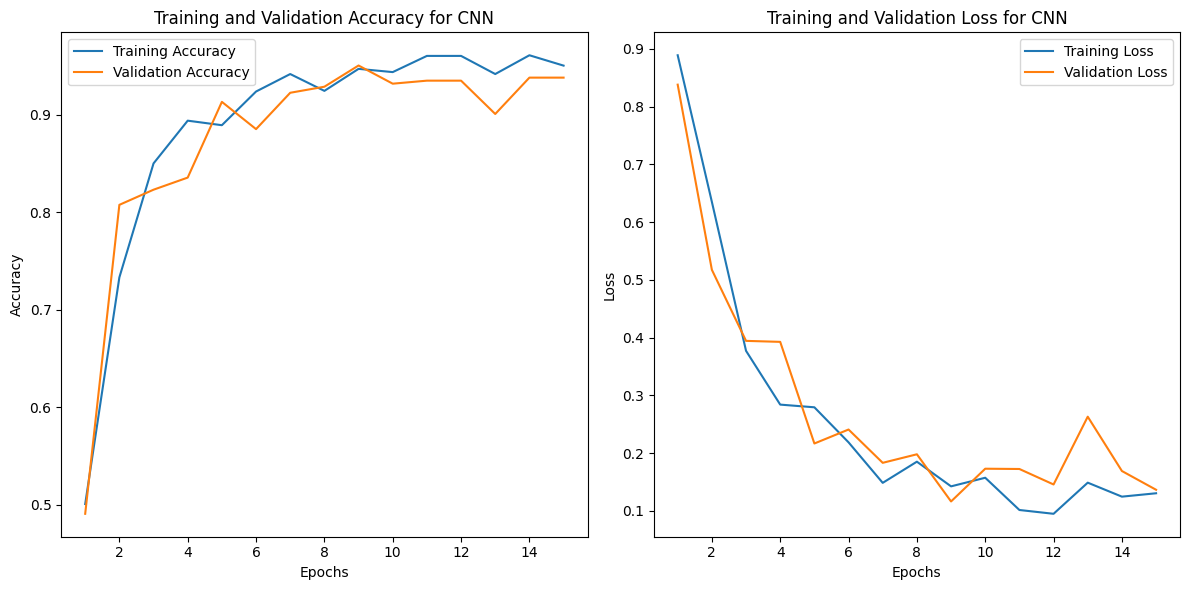

In [ ]:
# Retrieve metrics from the training history
acc = cnn.history['accuracy']
val_acc = cnn.history['val_accuracy']
loss = cnn.history['loss']
val_loss = cnn.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for CNN')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for CNN')
plt.legend()

plt.tight_layout()
plt.show()